# Fire, Ice & Flying Visitors
## Explainer Notebook — Social Data & Visualization (02806)
**Authors:** Eyjólfur - s252852 · Gunnlaugur - s252874 · Ívar - s252887

**Date:** Spring 2026

**Data sources:**
- Icelandic Tourist Board / Isavia — Keflavik Airport Departure Statistics (2002–2026)
- Central Bank of Iceland — ISK Exchange Rate Index (2002–2026)
- Google Trends — "flights to iceland" worldwide search interest (2004–2026)

---


## 1. Motivation

### What is our dataset?
We are working with three datasets:

1. **Visitor dataset** (`2002-2026-departures.xlsx`): Monthly departure counts through Keflavik Airport, broken down by country of origin. Covers 2002–2026, with 4,814 rows and 6 variables (`date`, `year`, `month`, `month_num`, `country`, `visitors`). Sourced from the Ferðamálastof - Icelandic Tourist Board, https://www.ferdamalastofa.is/en/recearch-and-statistics/numbers-of-foreign-visitors#nationalities-for-keflavik-airport-updated-monthly.

2. **ISK Exchange Rate** (`timeseries_byday_20020103_20260414.csv`): Daily ISK index values from the Central Bank of Iceland (Seðlabanki Íslands), 2002–2026. A higher index value indicates a weaker króna (more ISK needed per foreign currency unit). https://sedlabanki.is/gagnatorg/opinber-gengisskraning/?timeseries=4118&d_from=2002-03-04&d_to=2026-04-30&chart=1&date=2026-04-30&m_from=2025-04-30&y_from=2016&m_to=2026-04-30&y_to=2025#tab-12276c86-1823-49c9-b46e-cdccdfdbee1b

3. **Google Trends** (`time_series_Worldwide_20040101-0100_20260428-1020.csv`): Monthly search interest index (0–100) for the query "flights to iceland", worldwide, from 2004–2026. Sourced from Google Trends. https://trends.google.com/explore?q=flights%20to%20iceland&date=all&geo=Worldwide

### Why did we choose these datasets?
Iceland is an interesting case when it comes to tourism because its growth has been both rapid and a bit fragile. On its own, the visitor dataset is quite straightforward, it just shows monthly counts by country. But by combining it with the ISK exchange rate and Google search interest, we can go beyond simply describing trends and start trying to explain them.

Since we are from Iceland, we’ve seen this growth firsthand, which made the question more engaging for us. We wanted to explore what might have driven the boom, for example, whether a weaker króna made Iceland more affordable for tourists, or whether events like volcanic eruptions increased global attention. By bringing these three datasets together, we can visually explore and compare these possible explanations rather than just guessing.

### What was our goal for the end user experience?
We wanted to create a scrollytelling website that tells a clear and engaging story. It starts with Iceland’s modest beginnings as a tourism destination, then moves through the rapid growth between 2011 and 2018, the COVID crash, and the uneven recovery that followed.

Our goal was to make the story easy to understand, even for a non-technical reader, for example a friend from DTU who hasn’t taken this course. The website should feel more like reading an article than exploring a data dashboard.


---
## 2. Basic Stats

### Data Cleaning & Preprocessing

The raw visitor data comes from an Excel file with a fairly complex structure. It is split across multiple sheets and uses multiple header rows, where each year appears as a header followed by rows of countries.

To process this, we first detect the rows that contain the year. We then forward-fill the year column so each country row is labeled correctly. After that, we filter out only the valid country rows and reshape the data into a long format.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('2002-2026-departures.xlsx', header=None)

df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Visitors to Iceland through Keflavik airport 2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
3,Baltic states,1099,1638,2897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5634
4,Canada,1972,2125,3656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7753
5,China*,8908,14812,9827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33547
6,Denmark,1898,2664,2592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7154
7,France,5803,6396,5827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18026
8,Germany,6626,7785,9798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24209
9,Italy,7555,7380,5972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20907


In [21]:
df.columns = [
    'label', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Total'
]

df.head(10)

,label,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
0,Visitors to Iceland through Keflavik airport 2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
3,Baltic states,1099,1638,2897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5634
4,Canada,1972,2125,3656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7753
5,China*,8908,14812,9827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33547
6,Denmark,1898,2664,2592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7154
7,France,5803,6396,5827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18026
8,Germany,6626,7785,9798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24209
9,Italy,7555,7380,5972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20907


In [22]:
df['year'] = pd.to_numeric(df['label'], errors='coerce')
df[df['year'].notna()].head()

,label,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total,year
2,2026,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total,2026.0
21,2025,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total,2025.0
40,2024,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total,2024.0
59,2023,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total,2023.0
78,2022,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total,2022.0


In [23]:
df['year'] = df['year'].ffill()

In [24]:
df['label_str'] = df['label'].astype(str).str.strip()

mask_valid_country = (
    df['label'].notna() &
    ~df['label_str'].str.match(r'^\d{4}$') &    
    (df['label_str'] != 'Total') &              
    ~df['label_str'].str.startswith('*') &      
    ~df['label_str'].str.startswith('Source') & 
    ~df['label_str'].str.startswith('Visitors to Iceland') 
)

clean = df.loc[mask_valid_country, ['year', 'label', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']].copy()

clean = clean.rename(columns={'label': 'country'})
clean.head(20)

,year,country,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
3,2026.0,Baltic states,1099,1638,2897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026.0,Canada,1972,2125,3656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026.0,China*,8908,14812,9827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026.0,Denmark,1898,2664,2592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026.0,France,5803,6396,5827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2026.0,Germany,6626,7785,9798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026.0,Italy,7555,7380,5972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,2026.0,Netherlands,1743,2420,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,2026.0,Norway,984,1073,1460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2026.0,Poland,3860,4551,5547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
long_df = clean.melt(
    id_vars=['year', 'country'],
    value_vars=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    var_name='month',
    value_name='visitors'
)

long_df.head(20)

,year,country,month,visitors
0,2026.0,Baltic states,Jan,1099
1,2026.0,Canada,Jan,1972
2,2026.0,China*,Jan,8908
3,2026.0,Denmark,Jan,1898
4,2026.0,France,Jan,5803
5,2026.0,Germany,Jan,6626
6,2026.0,Italy,Jan,7555
7,2026.0,Netherlands,Jan,1743
8,2026.0,Norway,Jan,984
9,2026.0,Poland,Jan,3860


In [26]:
long_df['country'] = long_df['country'].str.replace('*', '', regex=False)
long_df['country'] = long_df['country'].str.strip()
long_df['country'] = long_df['country'].replace({
    'United States': 'USA',
    'United Kingdom': 'UK',
})

In [27]:
long_df['visitors'] = pd.to_numeric(long_df['visitors'], errors='coerce')
long_df = long_df.dropna(subset=['visitors']).copy()

In [28]:
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

long_df['month_num'] = long_df['month'].map(month_map)

long_df['date'] = pd.to_datetime(
    dict(year=long_df['year'].astype(int),
         month=long_df['month_num'],
         day=1)
)

long_df.head()

,year,country,month,visitors,month_num,date
0,2026.0,Baltic states,Jan,1099.0,1,2026-01-01
1,2026.0,Canada,Jan,1972.0,1,2026-01-01
2,2026.0,China,Jan,8908.0,1,2026-01-01
3,2026.0,Denmark,Jan,1898.0,1,2026-01-01
4,2026.0,France,Jan,5803.0,1,2026-01-01


In [29]:
long_df = long_df[['date', 'year', 'month', 'month_num', 'country', 'visitors']]
long_df = long_df.sort_values(['date', 'country']).reset_index(drop=True)

# Fix Icelandic 'Annað' -> 'Other'
long_df['country'] = long_df['country'].str.replace('Annað', 'Other', regex=False)

print(long_df.shape)
print('Countries:', long_df['country'].unique())
long_df.head(20)

# Save the cleaned data
long_df.to_csv("iceland_tourism_clean.csv", index=False)

(4814, 6)
Countries: ['Canada' 'Denmark' 'Finland' 'France' 'Germany' 'Italy' 'Japan'
 'Netherlands' 'Norway' 'Other' 'Spain' 'Sweden' 'Switzerland' 'UK' 'USA'
 'China' 'Poland' 'Russia' 'Baltic states']


### Load ISK Exchange Rate Data


In [30]:
# More simpler csv file
isk_raw = pd.read_csv('timeseries_byday_20020103_20260414.csv', sep=';', header=0)
isk_raw.columns = ['date', 'index', 'extra']
isk_raw['date']  = pd.to_datetime(isk_raw['date'], format='%d.%m.%Y')
isk_raw['index'] = isk_raw['index'].str.replace(',', '.').astype(float)
isk_raw = isk_raw.sort_values('date')

# Monthly average
isk_raw['month_period'] = isk_raw['date'].dt.to_period('M')
isk_monthly = isk_raw.groupby('month_period')['index'].mean().reset_index()
isk_monthly['date'] = isk_monthly['month_period'].dt.to_timestamp()

print(f'ISK rows: {len(isk_monthly)}')
print(f'Date range: {isk_monthly.date.min().date()} to {isk_monthly.date.max().date()}')
print(f'Min index (strongest ISK): {isk_monthly["index"].min():.1f}')
print(f'Max index (weakest ISK):   {isk_monthly["index"].max():.1f}')
isk_monthly.head()

ISK rows: 292
Date range: 2002-01-01 to 2026-04-01
Min index (strongest ISK): 100.7
Max index (weakest ISK):   237.2


,month_period,index,date
0,2002-01,133.170629,2002-01-01
1,2002-02,130.545770,2002-02-01
2,2002-03,130.263484,2002-03-01
3,2002-04,127.441850,2002-04-01
4,2002-05,123.682185,2002-05-01


### Load Google Trends Data


In [31]:
# More simpler csv file
gt = pd.read_csv('time_series_Worldwide_20040101-0100_20260428-1020.csv')
gt.columns = ['date', 'interest']
gt['date'] = pd.to_datetime(gt['date'])

print(f'Google Trends rows: {len(gt)}')
print(f'Date range: {gt.date.min().date()} to {gt.date.max().date()}')
print(f'Peak: {gt.interest.max()} in {gt.loc[gt.interest.idxmax(), "date"].strftime("%b %Y")}')
gt.head()

Google Trends rows: 268
Date range: 2004-01-01 to 2026-04-01
Peak: 100 in Apr 2010


,date,interest
0,2004-01-01,37
1,2004-02-01,32
2,2004-03-01,29
3,2004-04-01,32
4,2004-05-01,25


### Dataset Summary Stats


In [32]:
annual = long_df[long_df['year'] <= 2025].groupby('year')['visitors'].sum()

print('=== VISITOR DATASET ===')
print(f'Shape: {long_df.shape}')
print(f'Date range: {long_df.date.min().date()} to {long_df.date.max().date()}')
print(f'Countries: {long_df.country.nunique()} — {list(long_df.country.unique())}')
print(f'Missing values: {long_df.isnull().sum().sum()}')
print(f'Peak year: {int(annual.idxmax())} ({annual.max():,.0f} visitors)')
print(f'Growth 2002→2018: {annual[2018]/annual[2002]:.1f}x')
print(f'COVID drop 2019→2020: {(annual[2020]-annual[2019])/annual[2019]*100:.1f}%')


=== VISITOR DATASET ===
Shape: (4814, 6)
Date range: 2002-03-01 to 2026-03-01
Countries: 19 — ['Canada', 'Denmark', 'Finland', 'France', 'Germany', 'Italy', 'Japan', 'Netherlands', 'Norway', 'Other', 'Spain', 'Sweden', 'Switzerland', 'UK', 'USA', 'China', 'Poland', 'Russia', 'Baltic states']
Missing values: 0
Peak year: 2018 (2,315,925 visitors)
Growth 2002→2018: 9.3x
COVID drop 2019→2020: -75.7%


**Cleaning decisions:**
- **Visitor data**: Raw Excel has multi-level headers and mixed year/country/total rows. We detect year rows by checking if `label` parses as a 4-digit number, forward-fill the year, then filter out non-country rows (totals, footnotes, title rows). We melt from wide to long format, standardize country names (`United Kingdom → UK`, strip star from `China*`), convert visitors to numeric, and drop NaN rows (months not yet recorded).
- **ISK**: Semicolon delimiter, Icelandic decimal commas replaced with dots. Aggregated to monthly averages for alignment with visitor data.
- **Google Trends**: Already clean. Column renamed for clarity.
- **Partial year 2026** excluded from annual aggregations to avoid misleading comparisons.


---
## 3. Data Analysis

### 3.1 The Growth Story


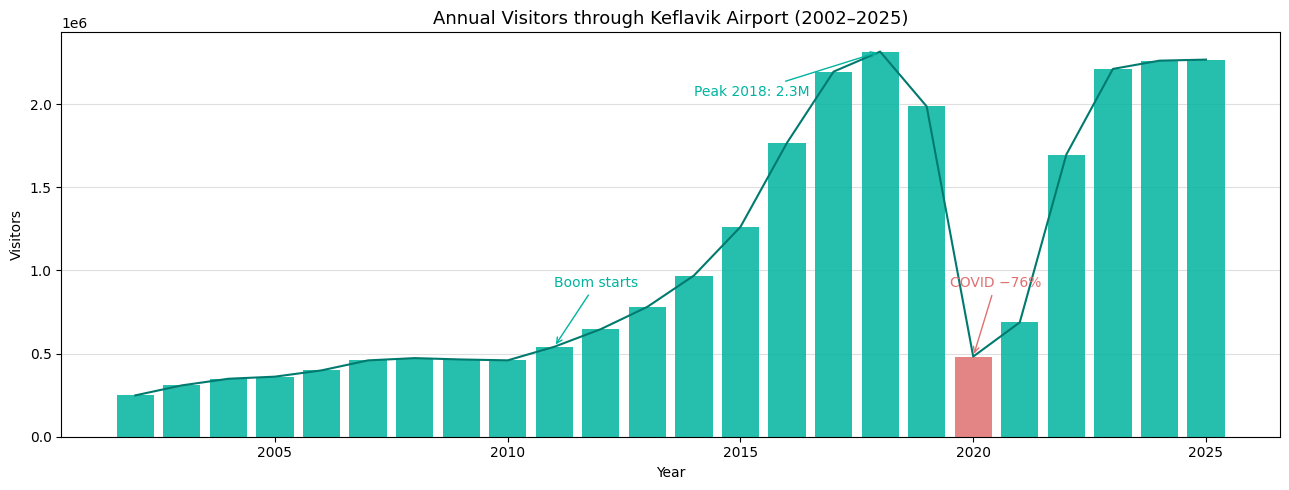

Growth from 2002 - 2018: 9.316618392469225
Annual growth:
 year
2002.0           NaN
2003.0     24.212728
2004.0     12.878601
2005.0      3.630646
2006.0     10.441683
2007.0     15.065894
2008.0      2.978874
2009.0     -1.721278
2010.0     -1.137479
2011.0     17.761926
2012.0     19.617658
2013.0     20.728188
2014.0     24.092336
2015.0     30.206638
2016.0     40.080258
2017.0     24.186158
2018.0      5.496087
2019.0    -14.239321
2020.0    -75.726543
2021.0     42.642520
2022.0    146.736543
2023.0     30.344622
2024.0      2.248213
2025.0      0.276246
Name: visitors, dtype: float64


In [33]:
fig, ax = plt.subplots(figsize=(13, 5))

annual_full = long_df[long_df.year <= 2025].groupby('year')['visitors'].sum()
bar_cols = ['#E07070' if y == 2020 else '#00B4A0' for y in annual_full.index]
ax.bar(annual_full.index, annual_full.values, color=bar_cols, alpha=0.85, zorder=2)
ax.plot(annual_full.index, annual_full.values, color='#007A6E', linewidth=1.5, zorder=3)

ax.annotate('Boom starts', xy=(2011, 540824), xytext=(2011, 900000),
            arrowprops=dict(arrowstyle='->', color='#00B4A0'), color='#00B4A0', fontsize=10)
ax.annotate('Peak 2018: 2.3M', xy=(2018, 2315925), xytext=(2014, 2050000),
            arrowprops=dict(arrowstyle='->', color='#00B4A0'), color='#00B4A0', fontsize=10)
ax.annotate('COVID −76%', xy=(2020, 482108), xytext=(2019.5, 900000),
            arrowprops=dict(arrowstyle='->', color='#E07070'), color='#E07070', fontsize=10)

ax.set_title('Annual Visitors through Keflavik Airport (2002–2025)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Visitors')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('growth.png', dpi=150, bbox_inches='tight')
plt.show()

v2002 = long_df[long_df.year == 2002]['visitors'].sum()
v2018 = long_df[long_df.year == 2018]['visitors'].sum()

ratio = v2018 / v2002
print("Growth from 2002 - 2018:", ratio)

annual = (
    long_df[long_df.year.between(2002, 2025)]
    .groupby('year')['visitors']
    .sum()
    .sort_index()
)

growth = annual.pct_change() * 100  # % growth
print("Annual growth:\n", growth)


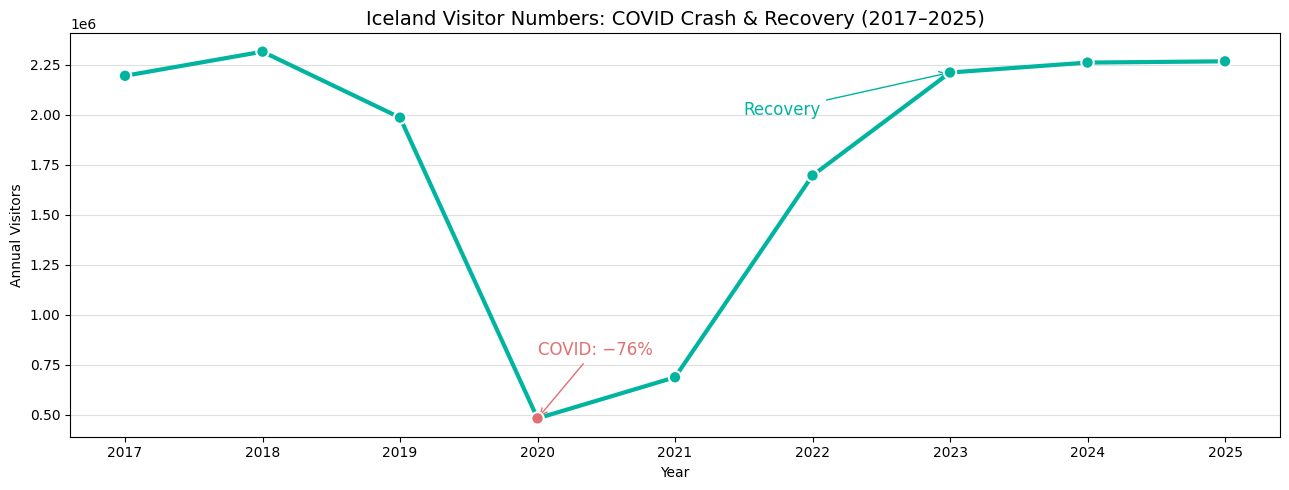

Drop from 2019 - 2020:  -75.72654271851161
Recovery in 2023 compared to 2020:  358.749491815112


In [34]:
annual_covid = (
    long_df[long_df['year'].between(2017, 2025)]
    .groupby('year')['visitors']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(annual_covid['year'], annual_covid['visitors'],
        color='#00B4A0', linewidth=3, zorder=3)

ax.scatter(annual_covid['year'], annual_covid['visitors'],
           color=annual_covid['visitors'].apply(lambda v: '#E07070' if v < 600000 else '#00B4A0'),
           s=80, zorder=4, edgecolors='white', linewidths=1.5)

ax.annotate('COVID: −76%',
            xy=(2020, 482108), xytext=(2020, 800000),
            arrowprops=dict(arrowstyle='->', color='#E07070'),
            color='#E07070', fontsize=12)

ax.annotate('Recovery',
            xy=(2023, 2211668), xytext=(2021.5, 2000000),
            arrowprops=dict(arrowstyle='->', color='#00B4A0'),
            color='#00B4A0', fontsize=12)

ax.set_title('Iceland Visitor Numbers: COVID Crash & Recovery (2017–2025)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Visitors')
ax.set_xticks(range(2017, 2026))
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('disruption.png', dpi=150, bbox_inches='tight')
plt.show()

v2019 = annual_covid.loc[annual_covid.year == 2019, 'visitors'].values[0]
v2020 = annual_covid.loc[annual_covid.year == 2020, 'visitors'].values[0]
v2023 = annual_covid.loc[annual_covid.year == 2023, 'visitors'].values[0]

covid_drop = (v2020 - v2019) / v2019 * 100
print("Drop from 2019 - 2020: ", covid_drop)

recovery_from_covid = (v2023 - v2020) / v2020 * 100
print("Recovery in 2023 compared to 2020: ", recovery_from_covid)


**Finding:** Iceland's tourism was essentially flat until 2011, then compounded at ~20–25% per year through 2018. COVID erased nearly a decade of growth overnight (−76% in a single year), but recovery was remarkably fast, pre-COVID levels were surpassed by 2023.


### 3.2 Seasonality. Is Iceland Really Year-Round?


In [35]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Build a long dataframe: year, month, visitors, season label
season_df = (
    long_df[long_df['year'].between(2002, 2025)]
    .groupby(['year', 'month_num'])['visitors']
    .sum()
    .reset_index()
)
season_df['month'] = season_df['month_num'].map(
    {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
     7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
)
season_df['season'] = season_df['month'].apply(
    lambda m: 'Summer (Jun–Aug)' if m in ['Jun','Jul','Aug'] else 'Rest of year'
)
season_df['year'] = season_df['year'].astype(int)

fig = px.bar(
    season_df,
    x='month',
    y='visitors',
    color='season',
    animation_frame='year',
    category_orders={'month': month_order, 'season': ['Summer (Jun–Aug)', 'Rest of year']},
    color_discrete_map={'Summer (Jun–Aug)': '#00B4A0', 'Rest of year': '#4A90A4'},
    labels={'visitors': 'Visitors', 'month': 'Month'},
    title='Monthly Visitors by Season (2002–2025)',
)

fig.update_layout(
    yaxis=dict(
        range=[0, 450000],
    ))

# Style the play button and slider
fig.layout.updatemenus[0].buttons[0].label = '▶  Play'
fig.layout.updatemenus[0].bgcolor = '#1B2E45'
fig.layout.updatemenus[0].bordercolor = '#00B4A0'
fig.layout.updatemenus[0].font = dict(color='white')

fig.write_html("monthly.html", include_plotlyjs="cdn")

fig.show()

annual_total = (
    long_df[long_df['year'].between(2002, 2025)]
    .groupby('year')['visitors']
    .sum()
)

jul_aug_total = (
    long_df[
        long_df['year'].between(2002, 2025)
        & long_df['month_num'].isin([7, 8])
    ]
    .groupby('year')['visitors']
    .sum()
)

jul_aug_share = (jul_aug_total / annual_total * 100).round(1)

print(jul_aug_share)
print("Average visitors in July and August:", jul_aug_share.mean().round(1))

year
2002.0    38.8
2003.0    36.1
2004.0    37.0
2005.0    36.2
2006.0    34.2
2007.0    35.3
2008.0    35.0
2009.0    37.5
2010.0    37.7
2011.0    36.9
2012.0    35.2
2013.0    32.7
2014.0    30.8
2015.0    29.3
2016.0    27.0
2017.0    25.3
2018.0    24.6
2019.0    24.3
2020.0    22.7
2021.0    38.1
2022.0    28.1
2023.0    25.1
2024.0    24.7
2025.0    27.1
Name: visitors, dtype: float64
Average visitors in July and August: 31.7


**Finding:** Summer (Jun–Aug) consistently accounts for vast majority of annual visitors. Despite heavy marketing of winter tourism (northern lights, Christmas), the seasonal distribution has barely shifted. Iceland is not yet a true year-round destination.


### 3.3 Origin Countries, Who's Coming?


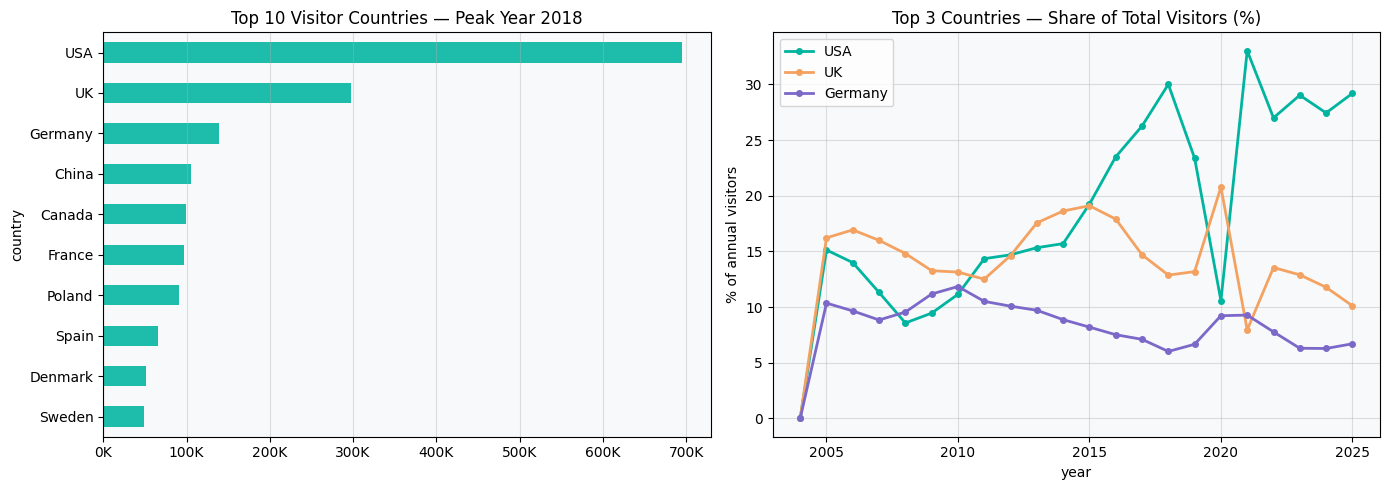

694814.0
297963.0
139155.0


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top countries 2018
top_2018 = (long_df[(long_df.year == 2018) & (long_df.country != 'Other')]
            .groupby('country')['visitors'].sum()
            .sort_values(ascending=True).tail(10))
top_2018.plot(kind='barh', ax=axes[0], color='#00B4A0', alpha=0.88)
axes[0].set_title('Top 10 Visitor Countries — Peak Year 2018')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[0].set_facecolor('#F7F9FB')
axes[0].grid(axis='x', alpha=0.4)

# USA / UK / Germany share over time
annual_total = long_df[long_df.year.between(2005, 2025)].groupby('year')['visitors'].sum()
for c, col in zip(['USA', 'UK', 'Germany'], ['#00B4A0', '#F4A261', '#7B68C8']):
    c_ann = long_df[(long_df.country == c) & long_df.year.between(2005, 2025)].groupby('year')['visitors'].sum()
    pct = (c_ann / annual_total * 100).reindex(range(2004, 2026), fill_value=0)
    pct.plot(ax=axes[1], label=c, color=col, linewidth=2, marker='o', markersize=4)

axes[1].set_title('Top 3 Countries — Share of Total Visitors (%)')
axes[1].set_ylabel('% of annual visitors')
axes[1].legend()
axes[1].set_facecolor('#F7F9FB')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('origins.png', dpi=150, bbox_inches='tight')
plt.show()

us_2018 = long_df[
    (long_df.country == 'USA') & (long_df.year == 2018)
]['visitors'].sum()

uk_2018 = long_df[
    (long_df.country == 'UK') & (long_df.year == 2018)
]['visitors'].sum()

germany_2018 = long_df[
    (long_df.country == 'Germany') & (long_df.year == 2018)
]['visitors'].sum()

print(us_2018)
print(uk_2018)
print(germany_2018)

**Finding:** The USA dominates with ~695K visitors in 2018, more than the next two countries combined. USA share peaked 2008–2010 and has been declining steadily since; top 3 still account for over 50%


### 3.4 ISK Exchange Rate vs Tourism


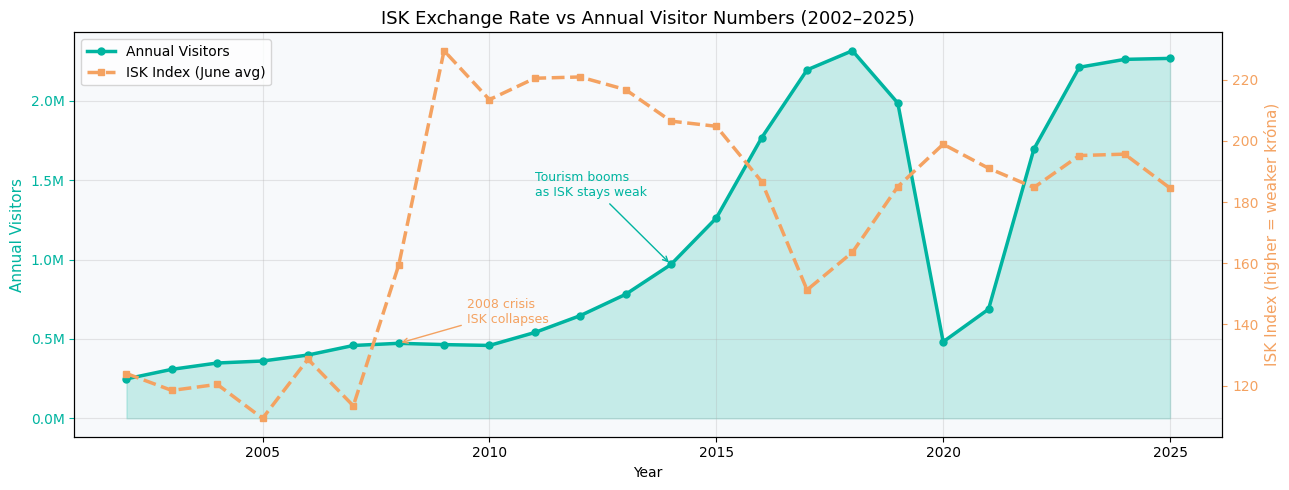

(0.24727343198076818, 0.24405138434019577)

In [37]:
fig, ax1 = plt.subplots(figsize=(13, 5))

annual_v = long_df[long_df.year.between(2002, 2025)].groupby('year')['visitors'].sum()
ax1.fill_between(annual_v.index, annual_v.values, alpha=0.2, color='#00B4A0')
ax1.plot(annual_v.index, annual_v.values, color='#00B4A0', linewidth=2.5,
         label='Annual Visitors', marker='o', markersize=5)
ax1.set_ylabel('Annual Visitors', color='#00B4A0', fontsize=11)
ax1.tick_params(axis='y', colors='#00B4A0')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

ax2 = ax1.twinx()
isk_raw['year'] = isk_raw['date'].dt.year
isk_raw['month'] = isk_raw['date'].dt.month
isk_annual = isk_raw[isk_raw.month == 6].groupby('year')['index'].mean()
isk_annual = isk_annual.loc[2002:2025]
ax2.plot(isk_annual.index, isk_annual.values, color='#F4A261', linewidth=2.5,
         linestyle='--', label='ISK Index (June avg)', marker='s', markersize=5)
ax2.set_ylabel('ISK Index (higher = weaker króna)', color='#F4A261', fontsize=11)
ax2.tick_params(axis='y', colors='#F4A261')

ax1.annotate('2008 crisis\nISK collapses', xy=(2008, 472672), xytext=(2009.5, 600000),
             arrowprops=dict(arrowstyle='->', color='#F4A261'), color='#F4A261', fontsize=9)
ax1.annotate('Tourism booms\nas ISK stays weak', xy=(2014, 969181), xytext=(2011, 1400000),
             arrowprops=dict(arrowstyle='->', color='#00B4A0'), color='#00B4A0', fontsize=9)

annual_isk = isk_monthly.set_index('date').resample('Y')['index'].mean()
annual_v = long_df[long_df.year.between(2002, 2025)].groupby('year')['visitors'].sum()

ax1.set_title('ISK Exchange Rate vs Annual Visitor Numbers (2002–2025)', fontsize=13)
ax1.set_xlabel('Year')
ax1.set_facecolor('#F7F9FB')
ax1.grid(alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('isk.png', dpi=150, bbox_inches='tight')
plt.show()

# Align years and compute
import scipy.stats as stats
r, p = stats.pearsonr(annual_isk.values[:len(annual_v)], annual_v.values)
r, p


**Finding:** There is a clear inverse relationship between the ISK index and visitor numbers. After the 2008 financial crisis, the króna weakened significantly (the index rose from around 120 to 235), making Iceland much cheaper for foreign visitors. This happened at roughly the same time that tourism began to take off.

As the króna strengthened again after 2016, the growth in visitor numbers slowed down, which supports the currency hypothesis. Of course, correlation does not imply causation, factors like airline expansion and social media exposure also played a role, but the timing is still striking.

A same-year Pearson correlation between annual ISK index and visitor numbers gives r = 0.25 (p = 0.24), which is not statistically significant. This does not refute the currency hypothesis, the chart shows the effect is clearly lagged, with tourism responding 2–3 years after currency shifts (the króna collapsed in 2008, but the visitor boom did not begin until 2011). 

### 3.5 Google Trends & Volcanic Events


In [38]:
# Prepare monthly visitor totals
monthly_visitors = (
    long_df[long_df.year <= 2025]
    .groupby('date')['visitors']
    .sum()
    .reset_index()
    .sort_values('date')
)

# All volcanic eruptions
volcanos = [
    ('2004-11-01', 'Grímsvötn (Nov 2004)',               '#E67E22', 'triangle-up', 3,  12),
    ('2010-03-01', 'Eyjafjallajökull (Mar 2010)',         '#C0392B', 'triangle-up', 2,  6),
    ('2010-04-01', 'Eyjafjallajökull (Apr 2010) ★',      '#C0392B', 'star',        3,  18),
    ('2011-05-01', 'Grímsvötn (May 2011)',                '#E67E22', 'triangle-up', 3,  12),
    ('2014-08-01', 'Holuhraun / Bárðarbunga (Aug 2014)', '#E67E22', 'triangle-up', 3,  12),
    ('2021-03-01', 'Fagradalsfjall (Mar 2021)',           '#8E44AD', 'triangle-up', 3,  12),
    ('2022-08-01', 'Meradalaeldar (Aug 2022)',            '#9B59B6', 'triangle-up', 3,  10),
    ('2023-07-01', 'Litli-Hrútur (Jul 2023)',             '#2980B9', 'triangle-up', 3,  10),
    ('2023-12-01', 'Sundhnúksgígur (Dec 2023)',           '#1ABC9C', 'triangle-up', 2,  6),
    ('2024-01-01', 'Svartsengi (Jan 2024) ★',            '#16A085', 'star',        2,  14),
    ('2024-02-01', 'Svartsengi (Feb 2024)',               '#16A085', 'triangle-up', 1,  4),
    ('2024-03-01', 'Svartsengi (Mar 2024)',               '#16A085', 'triangle-up', 1,  4),
    ('2024-05-01', 'Svartsengi (May 2024)',               '#16A085', 'triangle-up', 1,  4),
    ('2024-08-01', 'Svartsengi (Aug 2024)',               '#16A085', 'triangle-up', 1,  4),
    ('2024-11-01', 'Svartsengi (Nov 2024)',               '#16A085', 'triangle-up', 1,  4),
    ('2025-04-01', 'Svartsengi (Apr 2025)',               '#16A085', 'triangle-up', 1,  4),
    ('2025-07-01', 'Svartsengi (Jul 2025)',               '#16A085', 'triangle-up', 1,  4),
]

# Build figure with dual y-axes
fig = make_subplots(specs=[[{'secondary_y': True}]])

# Trace 1: Monthly visitors (teal bars, secondary y-axis)
fig.add_trace(go.Bar(
    x=monthly_visitors['date'],
    y=monthly_visitors['visitors'],
    name='Monthly Visitors',
    marker_color='rgba(0,180,160,0.35)',
    marker_line_width=0,
    hovertemplate='<b>%{x|%b %Y}</b><br>Visitors: %{y:,.0f}<extra></extra>',
), secondary_y=True)

# Trace 2: Google Trends line (orange, primary y-axis)
fig.add_trace(go.Scatter(
    x=gt['date'],
    y=gt['interest'],
    mode='lines',
    name='Google: "flights to iceland"',
    line=dict(color='#F4A261', width=2.5),
    hovertemplate='<b>%{x|%b %Y}</b><br>Search interest: %{y}<extra></extra>',
), secondary_y=False)

# Trace 3: Volcano scatter markers (primary y-axis, plotted at top)
seen = set()
for date_str, name, color, symbol, _, __ in volcanos:
    vdate = pd.to_datetime(date_str)
    match = gt[gt['date'] == vdate]['interest'].values
    yval = match[0] if len(match) > 0 else 25
    system = name.split('(')[0].strip().replace(' ★', '')
    show_legend = system not in seen
    seen.add(system)

    # Get visitor count for hover
    vmatch = monthly_visitors[monthly_visitors['date'] == vdate]['visitors'].values
    vcount = f"{int(vmatch[0]):,}" if len(vmatch) > 0 else 'N/A'

    fig.add_trace(go.Scatter(
        x=[vdate],
        y=[yval],
        mode='markers',
        name=system,
        legendgroup=system,
        showlegend=show_legend,
        marker=dict(
            color=color,
            size=15 if '★' in name else 11,
            symbol=symbol,
            line=dict(color='white', width=1.5)
        ),
        hovertemplate=(
            f'<b>{name}</b><br>'
            f'Search interest: {yval}<br>'
            f'Visitors that month: {vcount}'
            '<extra></extra>'
        ),
    ), secondary_y=False)

# COVID shading
fig.add_vrect(
    x0='2020-03-01', x1='2021-06-01',
    fillcolor='rgba(224,112,112,0.08)', line_width=0,
    annotation_text='COVID', annotation_position='top left',
    annotation=dict(font_color='#E07070', font_size=10)
)

# Zoom buttons
def zoom_btn(label, date_str, mb, ma):
    c = pd.to_datetime(date_str)
    return dict(
        label=label, method='relayout',
        args=[{'xaxis.range': [
            (c - pd.DateOffset(months=mb)).strftime('%Y-%m-%d'),
            (c + pd.DateOffset(months=ma)).strftime('%Y-%m-%d')
        ], 'xaxis.autorange': False}]
    )

buttons = [
    dict(label='Show All', method='relayout', args=[{'xaxis.autorange': True}]),
    zoom_btn('Grímsvötn 2004',     '2004-11-01', 3, 12),
    zoom_btn('Eyjafjallajökull *', '2010-04-01', 3, 18),
    zoom_btn('Grímsvötn 2011',     '2011-05-01', 3, 12),
    zoom_btn('Holuhraun',          '2014-08-01', 3, 12),
    zoom_btn('Fagradalsfjall',     '2021-03-01', 3, 12),
    zoom_btn('Meradalaeldar',      '2022-08-01', 3, 10),
    zoom_btn('Litli-Hrútur',       '2023-07-01', 3, 10),
    zoom_btn('Svartsengi *',       '2024-01-01', 2, 14),
]

# Layout
fig.update_layout(
    title=dict(
        text='Google Search Interest, Monthly Visitors & Volcanic Events (2004–2025)',
        font=dict(size=14)
    ),
    updatemenus=[dict(
        type='buttons', direction='right',
        x=0.0, y=1.22, xanchor='left',
        showactive=True,
        bgcolor='white', bordercolor='#DDE6ED',
        font=dict(size=11),
        buttons=buttons
    )],
    xaxis=dict(
        title='Date',
        showgrid=True, gridcolor='rgba(0,0,0,0.06)',
        rangeslider=dict(visible=True),
    ),
    yaxis=dict(
        title='Search Interest (0–100)',
        tickfont=dict(color='#F4A261'),
        showgrid=True, gridcolor='rgba(0,0,0,0.06)',
        range=[0, 120]
    ),
    yaxis2=dict(
        title='Monthly Visitors',
        tickfont=dict(color='#00B4A0'),
        showgrid=False,
        tickformat='.2s',
    ),
    plot_bgcolor='#F7F9FB',
    paper_bgcolor='white',
    legend=dict(
        title='Click to show/hide:',
        x=1.06, y=1,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='#DDE6ED', borderwidth=1
    ),
    height=570,
    margin=dict(t=130),
    hovermode='x unified',
    barmode='overlay',
    font=dict(family='Arial, sans-serif')
)

fig.show()
fig.write_html("volcano.html", include_plotlyjs="cdn")


**Finding:** The 2010 Eyjafjallajökull eruption scored a perfect 100 in Google Trends, the all-time peak in the dataset, driven by the disruption to European air travel. This did not immediately boost visitor numbers (2010 saw a dip), but the global awareness almost certainly seeded the boom that followed from 2011. The 2021–2024 Fagradalsfjall/Svartsengi series shows sustained elevated interest coinciding exactly with Iceland's post-COVID recovery.


---
## 4. Genre

We chose the **Martini Glass** genre (Segel & Heer, 2010).

The website begins with a tight, author-driven narrative. This guides the reader through the story in a fixed sequence (hook → growth → disruption → seasonality → origins → ISK → volcanos → conclusion). This is the bottom of the martini glass: linear, controlled, with a clear point of view. At the end, the reader enters the "bowl": an interactive country filter on the origins chart where they can freely explore visitor data across different years.

### Visual Narrative tools used (Figure 7, Segel & Heer):

| Category | Tool | How we used it |
|---|---|---|
| **Structure** | Establishing shot | Hero section opens with the 9× stat and aurora background to set the scene immediately |
| **Structure** | Progress bar | Fixed teal progress bar at top of page shows scroll position throughout the story |
| **Highlight** | Annotations | Chart annotations mark key moments: boom start (2011), COVID crash (2020), volcanic events |
| **Highlight** | Color emphasis | Summer months in teal vs muted blue; COVID bar in red; ISK line in orange |
| **Transition** | Consistent palette | Same color scheme (teal, navy, orange) across all sections and charts |

### Narrative Structure tools used (Figure 7, Segel & Heer):

| Category | Tool | How we used it |
|---|---|---|
| **Ordering** | Linear ordering | Scrollytelling enforces a fixed reading order: hook → growth → disruption → seasonality → origins → ISK → volcanos →  conclusion |
| **Ordering** | User-directed paths (end) | After the narrative, year filter buttons let readers explore the origins chart freely |
| **Interactivity** | Filtering | Year buttons on origins chart filter by year (2002, 2004, 2006,...) |
| **Interactivity** | Details on demand | Plotly hover tooltips reveal exact values on all charts |
| **Messaging** | Captions & intro text | Each section has a headline + 2–3 sentence narrative paragraph before the chart |
| **Messaging** | Summary / takeaway | Conclusion wraps the story with the thesis statement |


---
## 5. Visualizations

### Why these charts?

**Line chart — Annual growth (Section 1):**
A simple line chart over time is the clearest way to show the slow growth from 2002–2010 followed by the steep boom afterward. The shape of the curve, flat, then exponential, is immediately readable without explanation, which suits a non-scientific audience.

**Line chart with event annotations — Disruption (Section 2):**
Building on the same growth curve, we annotate the COVID-19 collapse directly on the line. The −76% drop and +359% recovery are highlighted as standalone stat callouts to reinforce the magnitude without cluttering the chart itself.

**Animated monthly bar chart — Seasonality (Section 3):**
Monthly bars sorted chronologically are the natural choice for calendar distributions. Adding a play button to animate across years (2002–2025) lets readers see that the summer-heavy pattern has barely shifted in over two decades, a finding that is much more convincing when shown dynamically than as a single static snapshot.

**Stacked/grouped chart — Origins (Section 4):**
Showing the top countries of origin over time makes it visible that the USA's dominance is gradually declining as Iceland's visitor base diversifies.

**Dual-axis line chart — ISK vs Visitors (Section 5):**
Placing visitors and the ISK exchange rate on the same timeline makes the inverse relationship immediately visible. The króna weakens after 2008, tourism takes off a few years later, the króna strengthens after 2016, growth stabilizes. A dual axis is appropriate here because both series need to be readable despite very different scales. 

**Interactive line chart with eruption markers — Google Trends & Volcanoes (Section 6):**
Vertical markers for volcanic events directly connect each eruption to its corresponding spike in search interest. Making this chart interactive, letting readers toggle between Eyjafjallajökull (2010), Holuhraun (2014–15), Fagradalsfjall (2021–23), and Svartsengi/Grindavík (2024–25), is essential because the comparison between eruptions is the point. A static version would force the reader to take our word for it, while the interactive version lets them verify the pattern themselves.

---
## 6. Discussion

### What went well?
- The three-dataset combination gives genuine analytical depth, we can tell a causal story, not just a descriptive one.
- The scrollytelling format fits the narrative arc naturally: growth → disruption → explanations.
- The volcanic events annotation is the most memorable moment on the website, visitors often have an suprising reaction seeing the 2010 spike.
- The dual-axis ISK chart communicates the currency hypothesis without requiring statistical knowledge.

### What is still missing / could be improved?
- **Activity data**: We could not find clean open data on what tourists actually *do* in Iceland (accommodation types, activities, spending patterns). This would have directly addressed Sune (teacher) feedback about visitor behavior.
- **Granular Google Trends**: Our data is monthly. Daily data around eruption events would show more precisely how fast interest spikes.
- **Spatial data**: All data is airport-level (Keflavik only). We cannot say where within Iceland tourists go.
- **Corrrelation**: A contemporaneous correlation cannot capture the delayed dynamic in the ISK graph. Other confounders (cheaper flights from low-cost carriers entering the market, the Eyjafjallajökull eruption's global publicity, social media growth) are also at play and not controlled for.

---
## 7. Contributions

| Task | Lead |
|---|---|
| Data collection & cleaning (visitor Excel) | Eyjólfur |
| Data collection & cleaning (ISK + Google Trends) | Gunnlaugur |
| Exploratory data analysis (all notebook plots) | Ívar |
| Website HTML/CSS/JS structure & scrollytelling | Eyjólfur |
| Plotly chart implementation on website | Ívar |
| Volcanic events research & annotations | Gunnlaugur |
| Written narrative text (website + notebook) | All three |
| Project A pitch video | All three |

All group members reviewed and understand every part of the assignment. The above reflects who took the lead role on each component.


---
## 8. References

1. Segel, E., & Heer, J. (2010). *Narrative Visualization: Telling Stories with Data*. IEEE Transactions on Visualization and Computer Graphics, 16(6), 1139–1148. https://doi.org/10.1109/TVCG.2010.179

2. Isavia / Icelandic Tourist Board. *Departures from Iceland through Keflavik Airport 2002–2026*. Retrieved from https://www.ferdamalastofa.is/en/recearch-and-statistics/numbers-of-foreign-visitors#nationalities-for-keflavik-airport-updated-monthly.

3. Seðlabanki Íslands (Central Bank of Iceland). *ISK Exchange Rate Index Time Series 2002–2026*. Retrieved from https://sedlabanki.is/gagnatorg/opinber-gengisskraning/?timeseries=4118&d_from=2002-03-04&d_to=2026-04-30&chart=1&date=2026-04-30&m_from=2025-04-30&y_from=2016&m_to=2026-04-30&y_to=2025#tab-12276c86-1823-49c9-b46e-cdccdfdbee1b

4. Google Trends. *Search interest: "flights to iceland" worldwide, 2004–2026*. Retrieved from https://trends.google.com/explore?q=flights%20to%20iceland&date=all&geo=Worldwide

5. Eldgosaannáll Íslands, Wikipedia: Retrieved from https://is.wikipedia.org/wiki/Eldgosaann%C3%A1ll_%C3%8Dslands